# Praktikum Modul 0 Mata Kuliah Kecerdasan Buatan dan Machine Learning

---

| | |
|---|---|
| **Nama** | Nabilah Anindya Paramesti |
| **NRP** | 5027241006 |
| **Kelas** | Kelas B |

---

Pada praktikum ini, kita akan menganalisis **Food Review Dataset** yang berisi tiga jenis data, yaitu **data tabular**, **teks ulasan**, dan **gambar makanan**. 

Tujuan utama pengerjaan ini adalah memahami struktur data, memilih fitur dan target yang sesuai, lalu melakukan **preprocessing** agar data siap digunakan untuk tugas **klasifikasi sentimen**.

Secara umum, langkah yang akan kita lakukan adalah:
1. Mengidentifikasi fitur dan target
2. Memahami tipe-tipe data pada dataset
3. Menganalisis data numerik dan kategorikal
4. Melakukan preprocessing pada data tabular
5. Membersihkan dan menyiapkan data teks
6. Menyiapkan data gambar agar siap diproses model

---
# Persiapan Awal

Sebelum masuk ke analisis utama, dilakukan persiapan lingkungan kerja agar proses eksplorasi dan preprocessing data dapat berjalan lebih terstruktur. 

Pada tahap ini, kita akan:
- mengimpor library yang dibutuhkan,
- mengatur tampilan notebook,
- menyiapkan path file dataset dan folder gambar,
- serta memuat dataset agar siap dianalisis pada soal berikutnya.

In [1]:
# =========================
# 1. Import library utama
# =========================
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from IPython.display import display

# =========================
# 2. Konfigurasi awal
# =========================
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup library dan konfigurasi awal berhasil dijalankan.")

Setup library dan konfigurasi awal berhasil dijalankan.


In [2]:
# =========================
# 3. Cek isi folder input Kaggle
# =========================
input_path = Path("/kaggle/input")

for path in input_path.iterdir():
    print(path)

/kaggle/input/datasets


In [3]:
# =========================
# 4. Cari file CSV secara otomatis
# =========================
csv_candidates = list(Path("/kaggle/input").rglob("food-review-dataset.csv"))
image_candidates = list(Path("/kaggle/input").rglob("images"))

print("CSV ditemukan di:")
for p in csv_candidates:
    print("-", p)

print("\nFolder images ditemukan di:")
for p in image_candidates:
    print("-", p)

# =========================
# 5. Set path dataset
# =========================
CSV_PATH = csv_candidates[0]
IMAGE_DIR = image_candidates[0]

CSV ditemukan di:
- /kaggle/input/datasets/revalinaf/food-review-dataset-modul-0-ai-2026/DatasetModul0AI2026/food-review-dataset.csv

Folder images ditemukan di:
- /kaggle/input/datasets/revalinaf/food-review-dataset-modul-0-ai-2026/DatasetModul0AI2026/images


In [4]:
# =========================
# 6. Load dataset
# =========================
df = pd.read_csv(CSV_PATH)

print("Shape dataset:", df.shape)
display(df.head())

Shape dataset: (3000, 14)


,review_id,restaurant_name,city,food_name,category,price,portion_size,rating_overall,rating_taste,rating_packaging,rating_delivery,review_text,image_name,sentiment_label
0,2824,Curry Kingdom,Semarang,Burger,Fast Food,22280,Small,4,4,5,4.0,"Makanannya enak banget, bakal order lagi.",img_001.jpg,positive
1,4257,Curry Kingdom,Solo,Biryani,Indian,30379,Medium,3,3,4,4.0,Tidak buruk tapi tidak spesial juga.,img_021.jpg,neutral
2,7224,Kopi Santai,Depok,Pizza,Fast Food,82357,Large,4,5,4,5.0,"Makanannya enak banget, bakal order lagi.",img_004.jpg,positive
3,6925,Sushi Mori,Yogyakarta,Donat,Dessert,46434,Small,4,3,3,3.0,Standar aja menurutku.,img_019.jpg,neutral
4,6820,Sushi Mori,Semarang,Udon,Japanese,93886,Large,3,3,4,4.0,Tidak buruk tapi tidak spesial juga.,img_007.jpg,neutral


# Soal 1 - Menentukan Fitur Relevan dan Target Variable

### Tujuan Analisis

Pada soal ini, tujuan perusahaan adalah membangun **sistem klasifikasi sentimen** dari data yang tersedia pada *Food Review Dataset*. Karena tugasnya adalah klasifikasi sentimen, maka kita perlu menentukan:

1. kolom mana yang layak digunakan sebagai **fitur**,
2. kolom mana yang paling tepat dijadikan **target variable**,
3. serta kolom mana yang sebaiknya **tidak digunakan** karena tidak relevan atau berpotensi menimbulkan **data leakage**.

Analisis ini penting karena performa model tidak hanya ditentukan oleh algoritma, tetapi juga oleh kualitas pemilihan fitur. Jika fitur yang digunakan tidak relevan, model akan sulit belajar pola yang benar. Sebaliknya, jika fitur terlalu dekat dengan target, model bisa terlihat sangat bagus saat evaluasi tetapi sebenarnya tidak benar-benar belajar secara adil.

### Target Variable

Kolom yang paling tepat dijadikan **target variable** adalah **`sentiment_label`**.

Alasannya adalah karena tujuan model pada soal ini adalah **memprediksi sentimen ulasan pelanggan**, sehingga target harus berupa label akhir yang merepresentasikan sentimen tersebut. Kolom `sentiment_label` secara langsung menunjukkan kelas sentimen dari setiap data, sehingga paling sesuai untuk dijadikan output yang diprediksi model.

Dengan kata lain:

- **input model** = fitur-fitur yang menggambarkan ulasan dan konteks pesanan,
- **output model** = `sentiment_label`.

Pemilihan ini logis karena target variable harus merepresentasikan hal yang ingin diprediksi, bukan sekadar informasi pendukung.

### Fitur yang Relevan untuk Pemodelan

#### 1. `review_text` sebagai fitur utama

Kolom **`review_text`** merupakan fitur yang **paling relevan** untuk klasifikasi sentimen.

Alasannya adalah karena sentimen pada dasarnya merupakan ekspresi opini pelanggan, dan opini paling langsung muncul pada teks ulasan. Dari teks ini, model dapat mempelajari kata-kata atau frasa yang menunjukkan kepuasan maupun ketidakpuasan, misalnya pujian terhadap rasa, keluhan terhadap pengiriman, atau komentar terhadap porsi dan kemasan.

Secara logis, jika tujuan model adalah memahami sentimen pelanggan, maka sumber informasi yang paling kaya adalah isi ulasan itu sendiri. Karena itu, `review_text` layak dijadikan **fitur utama**.

#### 2. Fitur tabular pendukung yang masih relevan

Selain teks ulasan, beberapa fitur tabular juga masih dapat digunakan sebagai **fitur pendukung**, yaitu:

- **`restaurant_name`**
- **`city`**
- **`food_name`**
- **`category`**
- **`price`**
- **`portion_size`**

##### a. `restaurant_name`
Nama restoran dapat membantu model mengenali pola tertentu yang mungkin berulang. Misalnya, beberapa restoran mungkin konsisten mendapatkan ulasan positif atau negatif karena kualitas makanan atau layanan yang relatif tetap.

Namun, kolom ini bukan sumber sentimen utama. Informasi ini hanya memberi konteks tambahan.

##### b. `city`
Kota juga dapat menjadi fitur pendukung karena pengalaman pelanggan bisa berbeda antar wilayah. Perbedaan ini bisa muncul akibat variasi layanan, waktu pengiriman, preferensi pelanggan, atau kualitas operasional di masing-masing kota.

##### c. `food_name`
Nama makanan atau minuman dapat membantu model memahami konteks isi review. Beberapa jenis menu mungkin lebih sering dikaitkan dengan keluhan tertentu, misalnya makanan berkuah terhadap kemasan, atau minuman dingin terhadap kualitas pengiriman.

#### d. `category`
Kategori makanan memberi informasi yang lebih umum dibanding `food_name`. Fitur ini berguna untuk menangkap pola sentimen pada kelompok makanan tertentu, misalnya dessert, makanan berat, minuman, dan sebagainya.

##### e. `price`
Harga dapat memengaruhi ekspektasi pelanggan. Makanan dengan harga tinggi biasanya menimbulkan harapan kualitas yang lebih tinggi. Akibatnya, sentimen pelanggan sering kali tidak hanya dipengaruhi kualitas makanan, tetapi juga oleh apakah harga tersebut dianggap sesuai.

##### f. `portion_size`
Ukuran porsi juga dapat memengaruhi tingkat kepuasan. Porsi yang dianggap terlalu kecil atau terlalu besar dapat muncul dalam ulasan dan berdampak pada sentimen akhir pelanggan.

Secara umum, fitur-fitur tabular ini tidak mengekspresikan sentimen secara langsung, tetapi tetap berguna sebagai **konteks tambahan** untuk membantu model memahami alasan di balik suatu sentimen.

### Fitur Gambar: Relevan, tetapi yang Dipakai adalah Isi Gambar, Bukan Nama File

Dataset ini bersifat multimodal, sehingga secara konsep **data gambar** juga relevan untuk pemodelan sentimen, terutama bila tampilan makanan memengaruhi kepuasan pelanggan.

Namun, yang perlu diperhatikan adalah bahwa kolom **`image_name`** **bukanlah fitur visual yang sesungguhnya**. Kolom ini hanya berisi nama file gambar, bukan isi gambar itu sendiri. Karena itu:

- **isi gambar** dapat dianggap relevan jika gambar benar-benar diproses,
- tetapi **`image_name` tidak boleh dipakai sebagai fitur langsung**.

Artinya, jika ingin menggunakan modalitas citra, maka gambar harus dibaca dari file lalu diubah menjadi representasi numerik, misalnya tensor piksel atau fitur hasil ekstraksi CNN. Nama file saja tidak memiliki makna visual bagi model.

### Fitur yang Berisiko Menyebabkan Data Leakage

Kolom berikut perlu diwaspadai:

- **`rating_overall`**
- **`rating_taste`**
- **`rating_packaging`**
- **`rating_delivery`**

Secara intuitif, kolom-kolom ini memang sangat informatif karena berkaitan langsung dengan pengalaman pelanggan. Namun, justru karena terlalu dekat dengan kepuasan pelanggan, fitur-fitur ini berpotensi menimbulkan **data leakage**.

#### Mengapa bisa terjadi data leakage?

Data leakage terjadi ketika model memperoleh informasi yang terlalu dekat, terlalu langsung, atau bahkan secara implisit sudah merepresentasikan target yang ingin diprediksi. Dalam kasus ini, rating diberikan oleh pelanggan dalam konteks evaluasi yang sama dengan sentimen. Jika seseorang memberi rating sangat tinggi, kemungkinan besar sentimennya positif. Jika rating sangat rendah, kemungkinan besar sentimennya negatif.

Akibatnya, model mungkin tidak benar-benar belajar memahami pola sentimen dari data yang lebih bermakna seperti teks ulasan, tetapi hanya “menebak” label dari rating yang sudah hampir setara dengan target.

#### Konsekuensi jika fitur rating digunakan

Jika fitur rating dipakai tanpa pertimbangan, performa model bisa tampak sangat tinggi saat evaluasi, tetapi hasil tersebut belum tentu mencerminkan kemampuan model yang sesungguhnya. Model mungkin hanya belajar hubungan sederhana antara rating dan label sentimen, bukan belajar memahami opini pelanggan secara lebih mendalam.

### Keputusan yang lebih aman

Untuk tugas **klasifikasi sentimen yang ingin benar-benar memprediksi sentimen dari ulasan pelanggan**, kolom rating sebaiknya:

- **tidak dijadikan fitur utama**, atau
- **bahkan dikeluarkan dari fitur pelatihan** jika tujuan analisis adalah membangun model sentimen yang adil dan tidak bias.

Dengan demikian, model lebih fokus mempelajari sinyal nyata dari teks dan konteks data lain, bukan dari skor yang sudah sangat dekat dengan label.

### Fitur yang Tidak Relevan

#### 1. `review_id`
Kolom **`review_id`** tidak relevan untuk pemodelan karena hanya merupakan identitas unik setiap data. Kolom seperti ini tidak mengandung informasi semantik mengenai sentimen pelanggan.

Jika dipakai, model justru berisiko mempelajari pola acak yang tidak memiliki makna umum dan tidak dapat digeneralisasi ke data baru.

#### 2. `image_name`
Seperti dijelaskan sebelumnya, `image_name` hanya nama file. Kolom ini tidak memuat informasi visual yang bisa dipahami model secara langsung. Karena itu, kolom ini tidak relevan jika dipakai apa adanya.

---

### Rekomendasi Pemilihan Fitur

Berdasarkan analisis di atas, pemilihan fitur yang paling logis adalah sebagai berikut.

#### Fitur utama
- **`review_text`**

#### Fitur pendukung
- **`restaurant_name`**
- **`city`**
- **`food_name`**
- **`category`**
- **`price`**
- **`portion_size`**

#### Fitur yang tidak digunakan langsung
- **`review_id`**
- **`image_name`**

#### Fitur yang perlu dihindari atau setidaknya diwaspadai karena potensi leakage
- **`rating_overall`**
- **`rating_taste`**
- **`rating_packaging`**
- **`rating_delivery`**

### Kesimpulan

Kolom yang paling tepat dijadikan **target variable** adalah **`sentiment_label`**, karena kolom ini secara langsung merepresentasikan label sentimen yang ingin diprediksi model.

Fitur yang paling relevan adalah **`review_text`** karena berisi opini langsung pelanggan, sehingga menjadi sumber utama informasi sentimen. Selain itu, fitur seperti **`restaurant_name`**, **`city`**, **`food_name`**, **`category`**, **`price`**, dan **`portion_size`** masih layak digunakan sebagai fitur pendukung karena memberikan konteks tambahan terhadap pengalaman pelanggan.

Sementara itu, **`review_id`** dan **`image_name`** tidak sebaiknya digunakan sebagai fitur langsung karena tidak mengandung informasi sentimen yang bermakna. Kolom rating seperti **`rating_overall`**, **`rating_taste`**, **`rating_packaging`**, dan **`rating_delivery`** juga perlu diwaspadai karena sangat dekat dengan target dan berpotensi menyebabkan **data leakage**.

Dengan demikian, untuk membangun model klasifikasi sentimen yang lebih adil dan bermakna, pendekatan yang paling aman adalah menggunakan **`review_text`** sebagai fitur utama, ditambah beberapa fitur konteks yang relevan, sambil menghindari fitur identitas dan fitur yang terlalu dekat dengan label.


In [5]:
target_col = "sentiment_label"

selected_features = [
    "review_text",
    "restaurant_name",
    "city",
    "food_name",
    "category",
    "price",
    "portion_size"
]

leakage_risk_features = [
    "rating_overall",
    "rating_taste",
    "rating_packaging",
    "rating_delivery"
]

excluded_features = [
    "review_id",
    "image_name"
]

print("Target:", target_col)
print("Selected features:", selected_features)
print("Leakage risk features:", leakage_risk_features)
print("Excluded features:", excluded_features)

Target: sentiment_label
Selected features: ['review_text', 'restaurant_name', 'city', 'food_name', 'category', 'price', 'portion_size']
Leakage risk features: ['rating_overall', 'rating_taste', 'rating_packaging', 'rating_delivery']
Excluded features: ['review_id', 'image_name']


# Soal 2 - Eksplorasi Awal Struktur Dataset

Pada tahap ini dilakukan eksplorasi awal untuk memahami struktur dataset sebelum masuk ke tahap preprocessing. Langkah ini penting karena dataset yang digunakan bersifat **multimodal**, sehingga setiap jenis data perlu dikenali terlebih dahulu agar dapat diproses dengan metode yang sesuai.

Eksplorasi awal ini mencakup:
- ukuran dataset,
- ringkasan setiap kolom,
- kondisi missing value,
- jumlah data duplikat,
- serta klasifikasi fitur berdasarkan jenis data analitis.

Hasil dari tahap ini akan menjadi dasar untuk menentukan teknik preprocessing yang tepat pada tahap berikutnya.

In [6]:
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

summary = pd.DataFrame({
    'Tipe Data'    : df.dtypes,
    'Non-Null'     : df.notnull().sum(),
    'Missing'      : df.isnull().sum(),
    'Unik'         : df.nunique(),
    'Contoh Nilai' : [
        df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        for col in df.columns
    ]
})

summary = summary.sort_values(by='Missing', ascending=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(summary)

print(f'Jumlah baris duplikat : {df.duplicated().sum()}')

Jumlah baris : 3000
Jumlah kolom : 14


,Tipe Data,Non-Null,Missing,Unik,Contoh Nilai
rating_delivery,float64,2925,75,5,4.0
review_text,object,2937,63,15,"Makanannya enak banget, bakal order lagi."
city,object,3000,0,8,Semarang
food_name,object,3000,0,21,Burger
review_id,int64,3000,0,3000,2824
restaurant_name,object,3000,0,10,Curry Kingdom
price,int64,3000,0,2952,22280
category,object,3000,0,7,Fast Food
portion_size,object,3000,0,3,Small
rating_overall,int64,3000,0,5,4


Jumlah baris duplikat : 0


In [7]:
numeric_cols = ['price', 'rating_overall', 'rating_taste', 'rating_packaging', 'rating_delivery']
categorical_cols = ['restaurant_name', 'city', 'food_name', 'category', 'portion_size']
text_cols = ['review_text']
image_cols = ['image_name']
identifier_cols = ['review_id']
target_col = 'sentiment_label'

feature_classification = pd.DataFrame({
    'Kolom': identifier_cols + numeric_cols + categorical_cols + text_cols + image_cols + [target_col],
    'Jenis Data Analitis': (
        ['Identifier'] * len(identifier_cols) +
        ['Numerik'] * len(numeric_cols) +
        ['Kategorikal'] * len(categorical_cols) +
        ['Teks'] * len(text_cols) +
        ['Citra'] * len(image_cols) +
        ['Target']
    )
})

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(feature_classification)

,Kolom,Jenis Data Analitis
0,review_id,Identifier
1,price,Numerik
2,rating_overall,Numerik
3,rating_taste,Numerik
4,rating_packaging,Numerik
5,rating_delivery,Numerik
6,restaurant_name,Kategorikal
7,city,Kategorikal
8,food_name,Kategorikal
9,category,Kategorikal


### Interpretasi Hasil

Berdasarkan hasil eksplorasi awal, dataset memiliki **3000 baris** dan **14 kolom**, sehingga jumlah data tergolong cukup untuk analisis awal. Secara umum, kondisi dataset juga cukup baik karena hampir semua kolom memiliki data lengkap.

Namun, masih terdapat missing value pada dua kolom, yaitu **`rating_delivery`** sebanyak **75 data** dan **`review_text`** sebanyak **63 data**. Hal ini menunjukkan bahwa pada tahap preprocessing nanti perlu dilakukan penanganan khusus terhadap kedua kolom tersebut, karena keduanya berpotensi penting dalam analisis sentimen.

Dari jumlah nilai uniknya, terlihat bahwa:
- **`review_id`** memiliki **3000 nilai unik**, sehingga kolom ini berperan sebagai identifier dan tidak relevan digunakan sebagai fitur utama.
- Kolom seperti **`city`**, **`category`**, dan **`portion_size`** memiliki jumlah kategori yang relatif sedikit, sehingga cocok dikategorikan sebagai **fitur kategorikal**.
- Kolom seperti **`price`**, **`rating_overall`**, **`rating_taste`**, **`rating_packaging`**, dan **`rating_delivery`** merupakan **fitur numerik**.
- Kolom **`review_text`** merupakan **fitur teks** yang sangat penting karena berisi opini pelanggan secara langsung.
- Kolom **`image_name`** merepresentasikan **data citra**, karena nilainya merujuk pada file gambar makanan.
- Kolom **`sentiment_label`** memiliki **3 nilai unik**, sehingga sesuai dijadikan **target klasifikasi sentimen**.

Secara keseluruhan, hasil ini menunjukkan bahwa dataset memiliki struktur yang cukup lengkap dan bersifat **multimodal**, karena menggabungkan data tabular, teks, dan citra dalam satu dataset.

# Soal 3 - Menentukan Fitur dan Target untuk Klasifikasi Sentimen

Pada tahap ini, ditentukan kolom yang akan digunakan sebagai **fitur** dan kolom yang akan dijadikan **target** pada tugas klasifikasi sentimen. Penentuan ini dilakukan agar model hanya menggunakan informasi yang relevan dan tidak memanfaatkan kolom yang berpotensi menimbulkan bias atau data leakage.

Fitur yang dipilih adalah:
- `review_text`
- `restaurant_name`
- `city`
- `food_name`
- `category`
- `price`
- `portion_size`

Target yang digunakan adalah:
- `sentiment_label`

Sementara itu, kolom berikut tidak digunakan dalam pemodelan:
- `review_id`
- `image_name`
- `rating_overall`
- `rating_taste`
- `rating_packaging`
- `rating_delivery`

Kolom `review_text` dipilih sebagai fitur utama karena berisi opini langsung pelanggan, sehingga paling relevan untuk klasifikasi sentimen. Fitur lain seperti `restaurant_name`, `city`, `food_name`, `category`, `price`, dan `portion_size` digunakan sebagai fitur pendukung karena dapat memberikan konteks tambahan terhadap pengalaman pelanggan.

Kolom `review_id` tidak digunakan karena hanya berfungsi sebagai identifier unik. Kolom `image_name` juga tidak digunakan secara langsung karena hanya berisi nama file, bukan isi visual gambar. Adapun kolom rating tidak digunakan karena berpotensi menyebabkan **data leakage**, mengingat nilainya sangat dekat dengan sentimen pelanggan.

Dengan demikian, fitur yang digunakan dalam pemodelan adalah kombinasi antara **teks ulasan** sebagai sumber utama informasi dan beberapa **fitur tabular pendukung**, sedangkan target yang diprediksi adalah **`sentiment_label`**.

In [14]:
selected_features = [
    'review_text',
    'restaurant_name',
    'city',
    'food_name',
    'category',
    'price',
    'portion_size'
]

target_col = 'sentiment_label'

excluded_features = [
    'review_id',
    'image_name',
    'rating_overall',
    'rating_taste',
    'rating_packaging',
    'rating_delivery'
]

feature_decision = pd.DataFrame({
    'Kolom': selected_features + excluded_features + [target_col],
    'Peran': (
        ['Fitur'] * len(selected_features) +
        ['Tidak digunakan'] * len(excluded_features) +
        ['Target']
    ),
    'Alasan': [
        'Sumber utama opini pelanggan',
        'Memberi konteks restoran',
        'Memberi konteks lokasi',
        'Memberi konteks jenis menu',
        'Memberi konteks kategori makanan',
        'Mewakili aspek harga',
        'Mewakili ukuran porsi',
        'Identifier unik',
        'Hanya nama file gambar',
        'Berpotensi data leakage',
        'Berpotensi data leakage',
        'Berpotensi data leakage',
        'Berpotensi data leakage',
        'Label sentimen yang diprediksi'
    ]
})

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(feature_decision)

,Kolom,Peran,Alasan
0,review_text,Fitur,Sumber utama opini pelanggan
1,restaurant_name,Fitur,Memberi konteks restoran
2,city,Fitur,Memberi konteks lokasi
3,food_name,Fitur,Memberi konteks jenis menu
4,category,Fitur,Memberi konteks kategori makanan
5,price,Fitur,Mewakili aspek harga
6,portion_size,Fitur,Mewakili ukuran porsi
7,review_id,Tidak digunakan,Identifier unik
8,image_name,Tidak digunakan,Hanya nama file gambar
9,rating_overall,Tidak digunakan,Berpotensi data leakage


### Kesimpulan

Fitur yang digunakan untuk klasifikasi sentimen adalah `review_text`, `restaurant_name`, `city`, `food_name`, `category`, `price`, dan `portion_size`, sedangkan target yang diprediksi adalah `sentiment_label`.

Kolom `review_id` dan `image_name` tidak digunakan karena tidak relevan sebagai input langsung. Sementara itu, kolom rating tidak digunakan karena berpotensi menimbulkan data leakage.

# Soal 4 - Analisis Fitur Numerik dan Deteksi Outlier

Pada tahap ini dilakukan analisis terhadap fitur numerik untuk memahami distribusi data dan mendeteksi kemungkinan adanya **outlier**. Analisis ini penting karena nilai ekstrem dapat memengaruhi statistik deskriptif, visualisasi, dan performa model machine learning.

Fitur numerik yang dianalisis adalah:
- `price`
- `rating_overall`
- `rating_taste`
- `rating_packaging`
- `rating_delivery`

Untuk mendeteksi outlier digunakan metode **Interquartile Range (IQR)**, yaitu dengan rumus:

- batas bawah = Q1 - 1.5 × IQR
- batas atas = Q3 + 1.5 × IQR

Nilai di luar rentang tersebut akan dianggap sebagai kandidat outlier. Namun, hasil deteksi ini tetap perlu ditafsirkan sesuai konteks masing-masing fitur. Hal ini penting karena tidak semua nilai ekstrem merupakan kesalahan data.

In [16]:
numeric_cols = ['price', 'rating_overall', 'rating_taste', 'rating_packaging', 'rating_delivery']

display(df[numeric_cols].describe().T)

numeric_summary = pd.DataFrame({
    'Missing': df[numeric_cols].isnull().sum(),
    'Missing (%)': (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)
})

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
price,3000.0,60776.344667,48262.552348,10085.0,34611.25,56928.5,78710.0,494038.0
rating_overall,3000.0,3.422000,1.397581,1.0,2.00,4.0,5.0,5.0
rating_taste,3000.0,3.411000,1.386141,1.0,2.00,4.0,4.0,5.0
rating_packaging,3000.0,3.416667,1.389616,1.0,2.00,4.0,5.0,5.0
rating_delivery,2925.0,3.403419,1.388339,1.0,2.00,4.0,4.0,5.0


,Missing,Missing (%)
price,0,0.0
rating_overall,0,0.0
rating_taste,0,0.0
rating_packaging,0,0.0
rating_delivery,75,2.5


Berdasarkan statistik deskriptif, fitur numerik dalam dataset terdiri dari satu fitur kontinu utama, yaitu **`price`**, serta empat fitur rating, yaitu **`rating_overall`**, **`rating_taste`**, **`rating_packaging`**, dan **`rating_delivery`**.

Kolom **`price`** memiliki rentang nilai yang cukup lebar, dari **10.085** hingga **494.038**, dengan rata-rata sekitar **60.776**. Selisih yang besar antara nilai minimum dan maksimum ini menunjukkan bahwa sebaran harga cukup bervariasi dan ada kemungkinan terdapat nilai ekstrem yang perlu diperiksa lebih lanjut pada tahap deteksi outlier.

Sementara itu, seluruh kolom rating memiliki rentang nilai **1 sampai 5**, yang sesuai dengan skala penilaian pelanggan. Nilai rata-rata semua rating berada di kisaran **3,4**, sehingga secara umum penilaian pelanggan cenderung berada pada tingkat sedang hingga baik.

Dari tabel missing value terlihat bahwa semua fitur numerik lengkap, kecuali **`rating_delivery`** yang memiliki **75 missing value** atau sekitar **2,5%** dari total data. Hal ini menunjukkan bahwa kolom tersebut perlu mendapatkan penanganan khusus pada tahap preprocessing berikutnya.

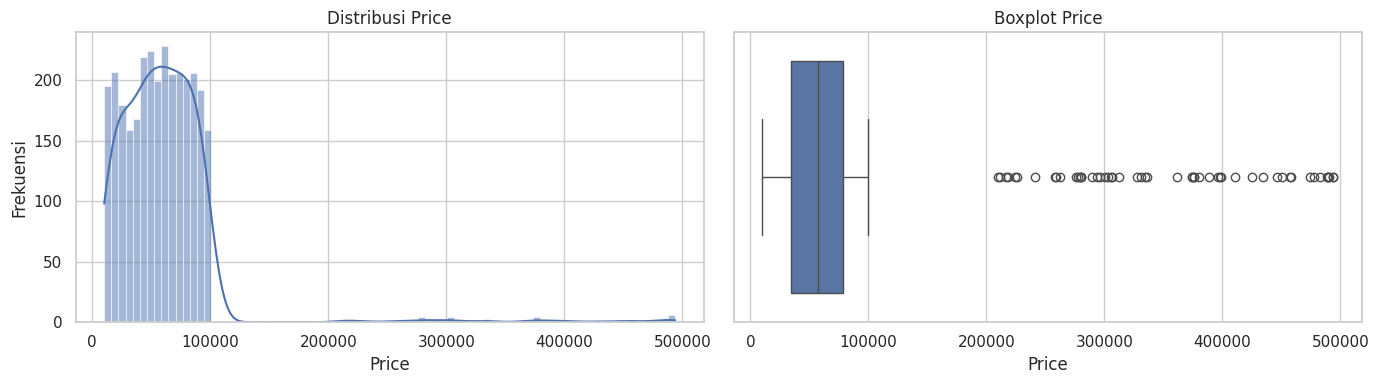

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frekuensi')

# Boxplot
sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('Boxplot Price')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

Histogram menunjukkan bahwa distribusi **`price`** cenderung **miring ke kanan (right-skewed)**. Sebagian besar data terkonsentrasi pada harga yang relatif lebih rendah, sedangkan hanya sedikit data yang memiliki harga sangat tinggi.

Boxplot juga menunjukkan adanya cukup banyak **nilai ekstrem** di sisi kanan, yang menandakan adanya kandidat outlier pada kolom `price`. Namun, nilai harga yang tinggi belum tentu merupakan kesalahan data, karena masih mungkin merepresentasikan menu dengan harga premium.

Dari hasil ini, dapat disimpulkan bahwa kolom `price` perlu diperhatikan dalam analisis outlier, tetapi nilai ekstremnya tidak sebaiknya langsung dihapus tanpa mempertimbangkan konteks bisnis.

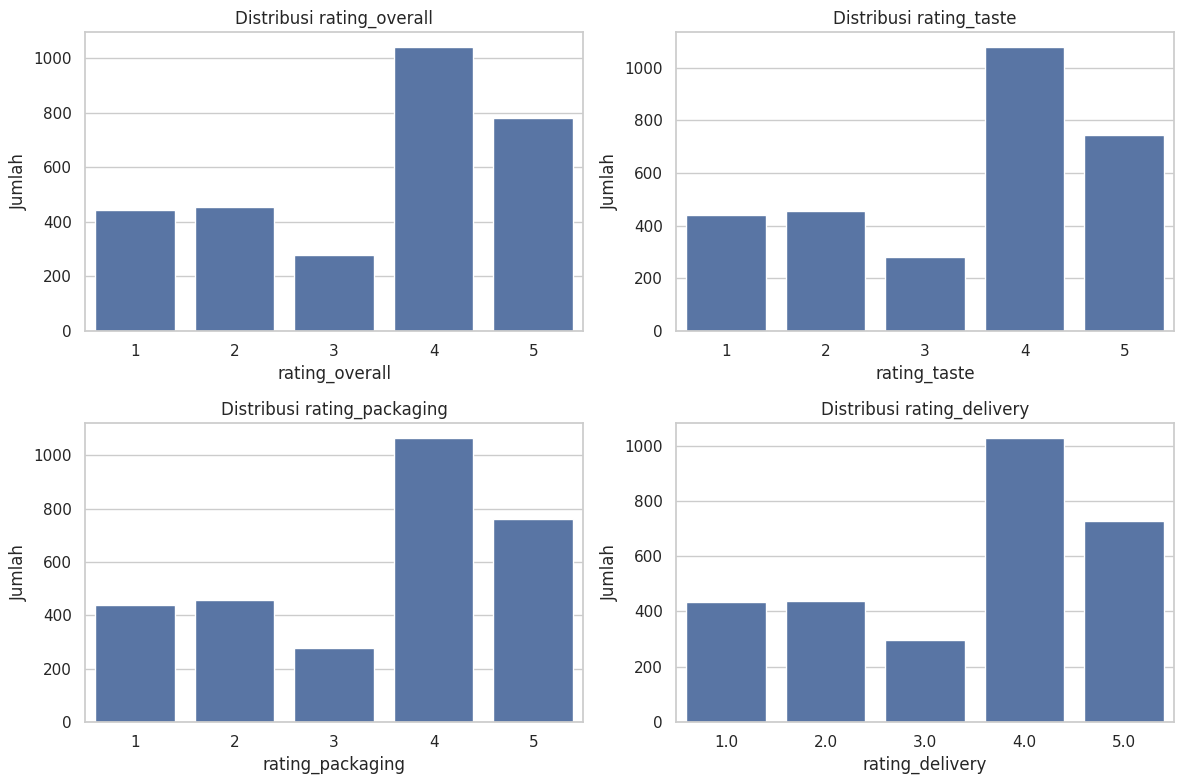

In [19]:
rating_cols = ['rating_overall', 'rating_taste', 'rating_packaging', 'rating_delivery']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(rating_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

Berdasarkan countplot, pola distribusi pada seluruh kolom rating terlihat cukup mirip. Nilai **4** muncul paling banyak pada `rating_overall`, `rating_taste`, `rating_packaging`, dan `rating_delivery`, kemudian diikuti oleh nilai **5**. Hal ini menunjukkan bahwa mayoritas pelanggan cenderung memberikan penilaian yang **baik hingga sangat baik**.

Sementara itu, rating **1**, **2**, dan **3** tetap ada, tetapi jumlahnya lebih sedikit dibanding rating tinggi. Artinya, meskipun terdapat beberapa ulasan dengan penilaian rendah, secara umum persepsi pelanggan terhadap makanan dan layanan dalam dataset ini cenderung positif.

Dari hasil ini juga terlihat bahwa kolom rating memiliki nilai yang terbatas pada skala **1 sampai 5**, sehingga distribusinya lebih tepat dibaca sebagai frekuensi penilaian pelanggan, bukan sebagai distribusi numerik kontinu.

In [20]:
outlier_summary = []

for col in numeric_cols:
    data = df[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = round((outlier_count / len(data)) * 100, 2)
    
    outlier_summary.append({
        'Kolom': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Jumlah Outlier': outlier_count,
        'Persentase Outlier (%)': outlier_pct
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,Kolom,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase Outlier (%)
0,price,34611.25,78710.0,44098.75,-31536.875,144858.125,53,1.77
1,rating_overall,2.00,5.0,3.00,-2.500,9.500,0,0.00
2,rating_taste,2.00,4.0,2.00,-1.000,7.000,0,0.00
3,rating_packaging,2.00,5.0,3.00,-2.500,9.500,0,0.00
4,rating_delivery,2.00,4.0,2.00,-1.000,7.000,0,0.00


Berdasarkan metode IQR, kolom **`price`** memiliki **53 outlier** atau sekitar **1,77%** dari total data. Hal ini menunjukkan bahwa terdapat sejumlah harga yang jauh lebih tinggi dibanding mayoritas data. Namun, nilai tersebut tidak langsung dianggap sebagai kesalahan, karena masih mungkin merepresentasikan menu dengan harga premium.

Sementara itu, kolom **`rating_overall`**, **`rating_taste`**, **`rating_packaging`**, dan **`rating_delivery`** tidak memiliki outlier berdasarkan perhitungan IQR. Hasil ini masuk akal karena seluruh kolom rating memiliki rentang nilai yang sempit dan terbatas pada skala penilaian tertentu.

Dengan demikian, perhatian utama dalam analisis outlier difokuskan pada kolom **`price`**, sedangkan kolom rating tidak menunjukkan adanya nilai ekstrem secara statistik.

In [21]:
for col in rating_cols:
    invalid_count = df[(df[col].notna()) & ((df[col] < 1) | (df[col] > 5))].shape[0]
    print(f'{col}: jumlah nilai di luar rentang 1–5 = {invalid_count}')

rating_overall: jumlah nilai di luar rentang 1–5 = 0
rating_taste: jumlah nilai di luar rentang 1–5 = 0
rating_packaging: jumlah nilai di luar rentang 1–5 = 0
rating_delivery: jumlah nilai di luar rentang 1–5 = 0


Hasil pengecekan menunjukkan bahwa seluruh kolom rating tidak memiliki nilai di luar rentang **1 sampai 5**. Artinya, tidak ditemukan indikasi kesalahan input pada fitur `rating_overall`, `rating_taste`, `rating_packaging`, maupun `rating_delivery`.

Hal ini menunjukkan bahwa seluruh nilai rating masih valid secara domain. Oleh karena itu, nilai rendah maupun tinggi pada kolom rating dapat dianggap sebagai variasi penilaian pelanggan yang wajar, bukan sebagai data yang salah.

Selanjutnya kita melihat pengaruh transformasi log pada price.

Tujuannya adalah membandingkan distribusi price sebelum transformasi dan sesudah transformasi log. Transformasi ini dipakai untuk mengurangi pengaruh nilai harga yang sangat besar agar distribusi menjadi lebih stabil.

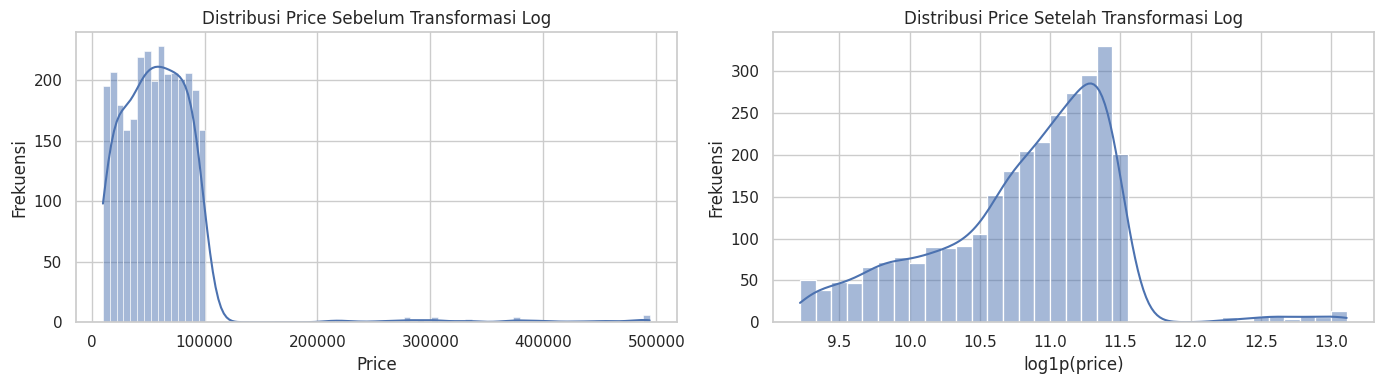

In [23]:
price_log = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Price Sebelum Transformasi Log')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frekuensi')

sns.histplot(price_log, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Price Setelah Transformasi Log')
axes[1].set_xlabel('log1p(price)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Sebelum transformasi log, distribusi **`price`** terlihat tidak merata karena masih dipengaruhi oleh beberapa nilai harga yang sangat tinggi. Hal ini membuat sebaran data cenderung melebar dan sulit dibaca secara lebih seimbang.

Setelah dilakukan transformasi log, distribusi `price` menjadi lebih stabil dan lebih terkonsentrasi. Pengaruh nilai harga yang sangat besar juga terlihat berkurang, sehingga pola distribusi data menjadi lebih mudah dianalisis.

Hasil ini menunjukkan bahwa transformasi log cukup efektif untuk mengurangi pengaruh nilai ekstrem pada kolom `price`. Oleh karena itu, transformasi log dapat dipertimbangkan sebagai langkah yang tepat jika fitur `price` akan digunakan pada tahap pemodelan.

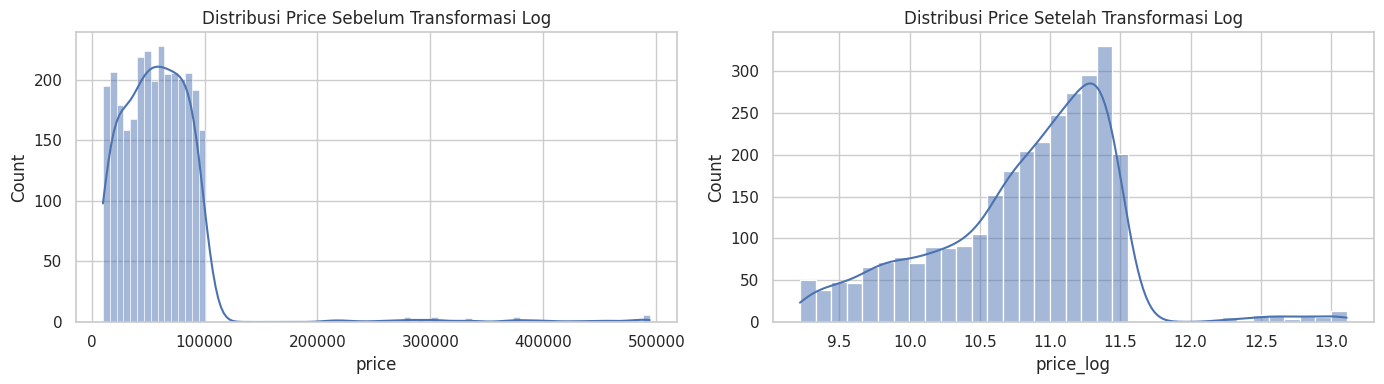

In [13]:
# Transformasi log untuk mengurangi skewness pada price
df['price_log'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Price Sebelum Transformasi Log')

sns.histplot(df['price_log'], kde=True, ax=axes[1])
axes[1].set_title('Distribusi Price Setelah Transformasi Log')

plt.tight_layout()
plt.show()

Sebelum transformasi log, distribusi **`price`** terlihat tidak merata karena masih dipengaruhi oleh beberapa nilai harga yang sangat tinggi. Hal ini membuat sebaran data cenderung melebar dan sulit dibaca secara lebih seimbang.

Setelah dilakukan transformasi log, distribusi `price` menjadi lebih stabil dan lebih terkonsentrasi. Pengaruh nilai harga yang sangat besar juga terlihat berkurang, sehingga pola distribusi data menjadi lebih mudah dianalisis.

Hasil ini menunjukkan bahwa transformasi log cukup efektif untuk mengurangi pengaruh nilai ekstrem pada kolom `price`. Oleh karena itu, transformasi log dapat dipertimbangkan sebagai langkah yang tepat jika fitur `price` akan digunakan pada tahap pemodelan.

### Kesimpulan

Berdasarkan analisis fitur numerik, kolom **`price`** merupakan fitur yang paling perlu diperhatikan dalam deteksi outlier karena memiliki rentang nilai yang sangat lebar dan distribusi yang tidak merata. Hasil visualisasi dan perhitungan IQR menunjukkan bahwa terdapat **53 outlier** atau sekitar **1,77%** dari total data pada kolom `price`. Namun, nilai harga yang tinggi tidak langsung dianggap sebagai kesalahan data, karena masih mungkin merepresentasikan menu dengan harga premium.

Sementara itu, kolom **`rating_overall`**, **`rating_taste`**, **`rating_packaging`**, dan **`rating_delivery`** memiliki nilai dalam rentang **1 sampai 5** dan tidak menunjukkan outlier berdasarkan metode IQR. Hasil validasi juga menunjukkan bahwa tidak ada nilai rating yang berada di luar rentang valid, sehingga seluruh nilai rating dapat dianggap wajar dan sesuai dengan domain penilaian pelanggan.

Selain itu, terdapat missing value pada kolom **`rating_delivery`** sebanyak **75 data** atau **2,5%**, sehingga kolom ini perlu ditangani pada tahap preprocessing berikutnya.

Penanganan outlier dapat dilakukan dengan beberapa cara, seperti menghapus data ekstrem, melakukan capping, transformasi data, atau menggunakan metode yang lebih robust terhadap outlier. Tidak ada satu metode yang selalu paling efektif untuk semua kasus. Pada dataset ini, pendekatan yang paling sesuai adalah tidak langsung menghapus outlier pada `price`, melainkan menggunakan transformasi log karena nilai harga yang tinggi masih mungkin valid secara bisnis. Sementara itu, kolom rating tidak memerlukan penanganan outlier karena seluruh nilainya masih berada pada rentang valid 1 sampai 5.

# Soal 5 - Preprocessing Data Tabular

Pada tahap ini dilakukan preprocessing terhadap **data tabular** yang akan digunakan dalam pemodelan. Data tabular yang diproses terdiri dari fitur kategorikal dan fitur numerik.

Fitur kategorikal perlu diubah ke format numerik karena model machine learning umumnya tidak dapat memproses data kategorikal dalam bentuk teks secara langsung. Sementara itu, fitur numerik juga perlu diperiksa dan ditransformasi bila diperlukan agar distribusinya lebih stabil dan sesuai untuk proses pemodelan.

Pada nomor ini, fokus preprocessing adalah:
- memilih fitur tabular yang akan digunakan,
- memisahkan fitur kategorikal dan numerik,
- mengubah fitur kategorikal menjadi representasi numerik,
- serta melakukan transformasi pada fitur numerik yang diperlukan.

In [24]:
tabular_features = ['restaurant_name', 'city', 'food_name', 'category', 'portion_size', 'price']
categorical_cols = ['restaurant_name', 'city', 'food_name', 'category', 'portion_size']
numeric_cols = ['price']
target_col = 'sentiment_label'

X_tabular = df[tabular_features].copy()
y = df[target_col].copy()

print("Fitur tabular yang digunakan:", tabular_features)
print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik:", numeric_cols)
print("Shape X_tabular:", X_tabular.shape)
print("Shape target:", y.shape)

display(X_tabular.head())
display(y.head())

Fitur tabular yang digunakan: ['restaurant_name', 'city', 'food_name', 'category', 'portion_size', 'price']
Kolom kategorikal: ['restaurant_name', 'city', 'food_name', 'category', 'portion_size']
Kolom numerik: ['price']
Shape X_tabular: (3000, 6)
Shape target: (3000,)


,restaurant_name,city,food_name,category,portion_size,price
0,Curry Kingdom,Semarang,Burger,Fast Food,Small,22280
1,Curry Kingdom,Solo,Biryani,Indian,Medium,30379
2,Kopi Santai,Depok,Pizza,Fast Food,Large,82357
3,Sushi Mori,Yogyakarta,Donat,Dessert,Small,46434
4,Sushi Mori,Semarang,Udon,Japanese,Large,93886


0    positive
1     neutral
2    positive
3     neutral
4     neutral
Name: sentiment_label, dtype: object

Berdasarkan hasil di atas, fitur tabular yang digunakan berjumlah **6 kolom**, yaitu lima fitur kategorikal (`restaurant_name`, `city`, `food_name`, `category`, `portion_size`) dan satu fitur numerik (`price`). Seluruh fitur ini dipilih karena dapat memberikan konteks tambahan terhadap sentimen pelanggan.

Bentuk data `X_tabular` adalah **(3000, 6)**, yang berarti terdapat **3000 baris data** dan **6 fitur tabular** yang akan diproses. Sementara itu, target `y` memiliki bentuk **(3000,)**, yang menunjukkan bahwa setiap baris data memiliki satu label sentimen yang sesuai.

Tampilan beberapa baris pertama juga menunjukkan bahwa fitur tabular berisi kombinasi informasi restoran, lokasi, jenis makanan, kategori, ukuran porsi, dan harga. Informasi ini nantinya akan diproses lebih lanjut agar dapat digunakan dalam model machine learning.

In [25]:
X_encoded = pd.get_dummies(X_tabular, columns=categorical_cols, drop_first=False)

print("Shape sebelum encoding :", X_tabular.shape)
print("Shape setelah encoding :", X_encoded.shape)

display(X_encoded.head())

Shape sebelum encoding : (3000, 6)
Shape setelah encoding : (3000, 50)


,price,restaurant_name_Bakso Legend,restaurant_name_Burger Hub,restaurant_name_Curry Kingdom,restaurant_name_Dapur Nusantara,restaurant_name_Grill Master,restaurant_name_Kedai Soto Ibu Rina,restaurant_name_Kopi Santai,restaurant_name_Ramen House,restaurant_name_Sushi Mori,restaurant_name_Taco Fiesta,city_Bandung,city_Bekasi,city_Depok,city_Jakarta,city_Semarang,city_Solo,city_Surabaya,city_Yogyakarta,food_name_Bakso,food_name_Biryani,food_name_Brownies,food_name_Burger,food_name_Cheesecake,food_name_Dimsum,food_name_Donat,food_name_Es Teh,food_name_Fried Chicken,food_name_Hot Dog,food_name_Ice Cream,food_name_Kopi Susu,food_name_Matcha Latte,food_name_Milkshake,food_name_Nasi Goreng,food_name_Pizza,food_name_Ramen,food_name_Rendang,food_name_Sate Ayam,food_name_Sushi,food_name_Udon,category_Beverage,category_Chinese,category_Dessert,category_Fast Food,category_Indian,category_Indonesian,category_Japanese,portion_size_Large,portion_size_Medium,portion_size_Small
0,22280,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,30379,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,82357,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
3,46434,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,93886,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False


Sebelum encoding, data tabular memiliki bentuk **(3000, 6)**. Setelah dilakukan **One-Hot Encoding**, bentuk data berubah menjadi **(3000, 50)**. Hal ini terjadi karena setiap kategori pada kolom kategorikal diubah menjadi kolom biner terpisah.

Sebagai contoh, kolom seperti `restaurant_name`, `city`, `food_name`, `category`, dan `portion_size` yang sebelumnya berupa teks, sekarang direpresentasikan dalam bentuk nilai **True/False** pada kolom-kolom baru. Dengan cara ini, informasi kategorikal dapat dipahami oleh model machine learning.

Perubahan jumlah kolom dari 6 menjadi 50 menunjukkan bahwa fitur kategorikal memiliki beberapa variasi kategori, sehingga setelah encoding jumlah fitur bertambah cukup signifikan. Namun, langkah ini memang diperlukan agar data kategorikal dapat digunakan dalam proses pemodelan.

In [26]:
X_encoded['price_log'] = np.log1p(X_encoded['price'])

display(X_encoded[['price', 'price_log']].head())

,price,price_log
0,22280,10.011490
1,30379,10.321540
2,82357,11.318831
3,46434,10.745809
4,93886,11.449847


Output di atas menunjukkan hasil transformasi log pada kolom **`price`** menjadi **`price_log`** menggunakan fungsi `log1p()`. Transformasi ini dilakukan untuk mengurangi pengaruh nilai harga yang sangat besar dan membuat distribusi data menjadi lebih stabil.

Terlihat bahwa nilai pada `price_log` memiliki skala yang lebih kecil dibanding `price` asli. Misalnya, harga **22280** berubah menjadi sekitar **10.01**, sedangkan harga **93886** berubah menjadi sekitar **11.45**. Hal ini menunjukkan bahwa transformasi log berhasil menekan perbedaan antar nilai harga yang terlalu jauh.

Dengan demikian, `price_log` lebih cocok digunakan pada tahap pemodelan dibanding `price` asli, terutama jika ingin mengurangi dampak nilai ekstrem pada fitur harga.

Selanjutnya kita akan menyiapkan dataset tabular final. Di tahap ini, kita akan:
* memakai hasil encoding kategorikal
* memakai price_log sebagai representasi numerik utama
* dan menghapus price asli supaya tidak ada dua versi fitur harga yang dipakai bersamaan.

In [27]:
X_tabular_final = X_encoded.drop(columns=['price']).copy()

print("Shape data tabular final:", X_tabular_final.shape)
display(X_tabular_final.head())

Shape data tabular final: (3000, 50)


,restaurant_name_Bakso Legend,restaurant_name_Burger Hub,restaurant_name_Curry Kingdom,restaurant_name_Dapur Nusantara,restaurant_name_Grill Master,restaurant_name_Kedai Soto Ibu Rina,restaurant_name_Kopi Santai,restaurant_name_Ramen House,restaurant_name_Sushi Mori,restaurant_name_Taco Fiesta,city_Bandung,city_Bekasi,city_Depok,city_Jakarta,city_Semarang,city_Solo,city_Surabaya,city_Yogyakarta,food_name_Bakso,food_name_Biryani,food_name_Brownies,food_name_Burger,food_name_Cheesecake,food_name_Dimsum,food_name_Donat,food_name_Es Teh,food_name_Fried Chicken,food_name_Hot Dog,food_name_Ice Cream,food_name_Kopi Susu,food_name_Matcha Latte,food_name_Milkshake,food_name_Nasi Goreng,food_name_Pizza,food_name_Ramen,food_name_Rendang,food_name_Sate Ayam,food_name_Sushi,food_name_Udon,category_Beverage,category_Chinese,category_Dessert,category_Fast Food,category_Indian,category_Indonesian,category_Japanese,portion_size_Large,portion_size_Medium,portion_size_Small,price_log
0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,10.011490
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,10.321540
2,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,11.318831
3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,10.745809
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,11.449847


Output di atas menunjukkan bahwa data tabular final sudah berada dalam bentuk numerik dan siap digunakan untuk tahap pemodelan. Seluruh fitur kategorikal telah diubah menjadi kolom biner melalui **One-Hot Encoding**, sedangkan fitur numerik `price` telah digantikan oleh **`price_log`** yang lebih stabil.

Dari tampilan beberapa baris pertama, terlihat bahwa setiap kategori sekarang direpresentasikan dalam bentuk nilai **True/False**, yang menunjukkan keberadaan suatu kategori pada baris data tertentu. Sementara itu, `price_log` menjadi representasi numerik utama untuk fitur harga.

Dengan demikian, dataset tabular final sudah berhasil diproses sehingga seluruh fiturnya dapat dipahami oleh algoritma machine learning.

### Kesimpulan

Pada tahap preprocessing data tabular, fitur yang digunakan terdiri dari lima fitur kategorikal (`restaurant_name`, `city`, `food_name`, `category`, `portion_size`) dan satu fitur numerik (`price`). Fitur kategorikal diubah menjadi representasi numerik menggunakan **One-Hot Encoding**, sehingga jumlah kolom bertambah dari 6 menjadi 50.

Selain itu, karena kolom `price` memiliki distribusi yang tidak merata dan mengandung nilai ekstrem, dilakukan transformasi log untuk menghasilkan fitur **`price_log`** yang lebih stabil. Setelah `price` asli dihapus dan digantikan oleh `price_log`, diperoleh dataset tabular final yang seluruh fiturnya sudah berada dalam bentuk numerik dan siap digunakan untuk tahap pemodelan.

# Soal 6 - Preprocessing Data Teks

Pada tahap ini dilakukan preprocessing pada data teks, yaitu kolom **`review_text`**. Langkah ini penting karena teks mentah biasanya masih mengandung huruf kapital, tanda baca, angka, atau spasi berlebih yang dapat mengganggu proses analisis.

Tujuan preprocessing teks adalah mengubah ulasan menjadi bentuk yang lebih bersih dan konsisten agar lebih mudah diolah pada tahap representasi fitur dan pemodelan. Pada nomor ini, proses dilakukan secara bertahap mulai dari menyiapkan data teks, membersihkan teks, hingga mengubahnya ke bentuk numerik.

In [28]:
text_col = 'review_text'

X_text = df[[text_col]].copy()

print("Jumlah data teks:", X_text.shape[0])
print("Jumlah missing value pada review_text:", X_text[text_col].isnull().sum())

display(X_text.head(10))

Jumlah data teks: 3000
Jumlah missing value pada review_text: 63


,review_text
0,"Makanannya enak banget, bakal order lagi."
1,Tidak buruk tapi tidak spesial juga.
2,"Makanannya enak banget, bakal order lagi."
3,Standar aja menurutku.
4,Tidak buruk tapi tidak spesial juga.
5,Enak pol! Pengiriman juga cepat.
6,"Makanannya enak banget, bakal order lagi."
7,Rasanya biasa aja sih.
8,Datangnya lama dan rasanya kurang enak.
9,Kapok pesan di sini.


Berdasarkan hasil di atas, kolom **`review_text`** memiliki **3000 data**, dengan **63 missing value**. Hal ini menunjukkan bahwa sebagian besar data teks tersedia, tetapi tetap diperlukan penanganan terhadap nilai kosong pada tahap preprocessing agar tidak mengganggu proses analisis.

Dari beberapa contoh ulasan yang ditampilkan, terlihat bahwa data teks berisi kalimat-kalimat pendek yang secara langsung menggambarkan opini pelanggan terhadap makanan dan layanan. Selain itu, beberapa ulasan tampak berulang, sehingga variasi teks dalam dataset kemungkinan tidak terlalu besar.

Karena kolom `review_text` merupakan sumber utama informasi sentimen, maka tahap pembersihan teks menjadi penting agar isi ulasan lebih konsisten dan siap diubah ke bentuk numerik pada langkah berikutnya.

In [29]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()                          # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # hapus tanda baca dan angka
    text = re.sub(r'\s+', ' ', text).strip()    # rapikan spasi
    return text

X_text['review_text_clean'] = X_text[text_col].apply(clean_text)

display(X_text[[text_col, 'review_text_clean']].head(10))

,review_text,review_text_clean
0,"Makanannya enak banget, bakal order lagi.",makanannya enak banget bakal order lagi
1,Tidak buruk tapi tidak spesial juga.,tidak buruk tapi tidak spesial juga
2,"Makanannya enak banget, bakal order lagi.",makanannya enak banget bakal order lagi
3,Standar aja menurutku.,standar aja menurutku
4,Tidak buruk tapi tidak spesial juga.,tidak buruk tapi tidak spesial juga
5,Enak pol! Pengiriman juga cepat.,enak pol pengiriman juga cepat
6,"Makanannya enak banget, bakal order lagi.",makanannya enak banget bakal order lagi
7,Rasanya biasa aja sih.,rasanya biasa aja sih
8,Datangnya lama dan rasanya kurang enak.,datangnya lama dan rasanya kurang enak
9,Kapok pesan di sini.,kapok pesan di sini


Hasil di atas menunjukkan bahwa preprocessing berhasil membersihkan teks pada kolom **`review_text`**. Setelah dibersihkan, seluruh huruf berubah menjadi **huruf kecil**, tanda baca dihapus, angka dihilangkan, dan spasi berlebih dirapikan.

Sebagai contoh, teks **"Makanannya enak banget, bakal order lagi."** berubah menjadi **"makanannya enak banget bakal order lagi"**. Perubahan ini membuat teks menjadi lebih konsisten tanpa mengubah makna utama dari ulasan.

Langkah pembersihan ini penting karena model machine learning tidak membutuhkan variasi penulisan seperti huruf kapital atau tanda baca, melainkan pola kata yang muncul dalam ulasan. Dengan demikian, teks yang sudah dibersihkan akan lebih siap untuk diubah ke bentuk numerik pada tahap berikutnya.

In [30]:
print("Jumlah missing value setelah cleaning :", X_text['review_text_clean'].isnull().sum())
print("Jumlah teks unik sebelum cleaning      :", X_text[text_col].nunique(dropna=True))
print("Jumlah teks unik setelah cleaning      :", X_text['review_text_clean'].nunique(dropna=True))

Jumlah missing value setelah cleaning : 0
Jumlah teks unik sebelum cleaning      : 15
Jumlah teks unik setelah cleaning      : 16


Setelah proses cleaning, jumlah missing value pada kolom **`review_text_clean`** menjadi **0**. Hal ini terjadi karena nilai kosong sebelumnya diubah menjadi string kosong, sehingga tidak lagi terbaca sebagai missing value oleh Pandas.

Selain itu, jumlah teks unik berubah dari **15** menjadi **16**. Perubahan ini menunjukkan bahwa proses cleaning memengaruhi representasi teks, sehingga ada kemungkinan beberapa teks yang sebelumnya berbeda menjadi lebih konsisten, atau nilai kosong ikut terbentuk sebagai satu bentuk teks tersendiri.

Hasil ini menunjukkan bahwa data teks sudah berada dalam kondisi yang lebih bersih dan konsisten, sehingga siap digunakan pada tahap representasi numerik berikutnya.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X_text['review_text_clean'])

print("Shape hasil TF-IDF:", X_tfidf.shape)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

display(tfidf_df.head())

Shape hasil TF-IDF: (3000, 52)


,aja,aneh,bakal,banget,berantakan,biasa,bisa,buruk,cepat,cukup,dan,datangnya,di,ditingkatkan,ekspektasi,enak,hambar,harga,ini,juara,juga,kapok,kecewa,kurang,lagi,lah,lama,lumayan,makanannya,mantap,masih,menurutku,oke,order,packingnya,pengiriman,pesan,pol,rapi,rasanya,recommended,sama,segitu,sesuai,sih,sini,spesial,standar,suka,tapi,tidak,untuk
0,0.000000,0.0,0.452355,0.277635,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.323139,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.452355,0.0,0.0,0.0,0.452355,0.0,0.0,0.000000,0.0,0.452355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.421656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.293064,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.421656,0.000000,0.0,0.351334,0.659614,0.0
2,0.000000,0.0,0.452355,0.277635,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.323139,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.452355,0.0,0.0,0.0,0.452355,0.0,0.0,0.000000,0.0,0.452355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0.494262,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.614697,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.614697,0.0,0.000000,0.000000,0.0
4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.421656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.293064,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.421656,0.000000,0.0,0.351334,0.659614,0.0


Hasil TF-IDF menunjukkan bahwa kolom `review_text_clean` berhasil diubah menjadi representasi numerik dengan bentuk **(3000, 52)**. Artinya, terdapat **3000 dokumen** dan **52 kata unik** yang digunakan sebagai fitur teks.

Setiap kolom pada hasil TF-IDF merepresentasikan satu kata, sedangkan nilainya menunjukkan bobot pentingnya kata tersebut pada suatu ulasan. Semakin besar nilai TF-IDF, semakin besar kontribusi kata tersebut dalam merepresentasikan isi ulasan tertentu.

Dengan demikian, data teks yang semula berupa kalimat sudah berhasil diubah ke bentuk numerik yang dapat diproses oleh model machine learning.

,kata,frekuensi
0,rasanya,1575
1,banget,1069
2,enak,766
3,packingnya,481
4,sih,457
5,juga,395
6,tidak,374
7,dan,363
8,juara,313
9,ini,313


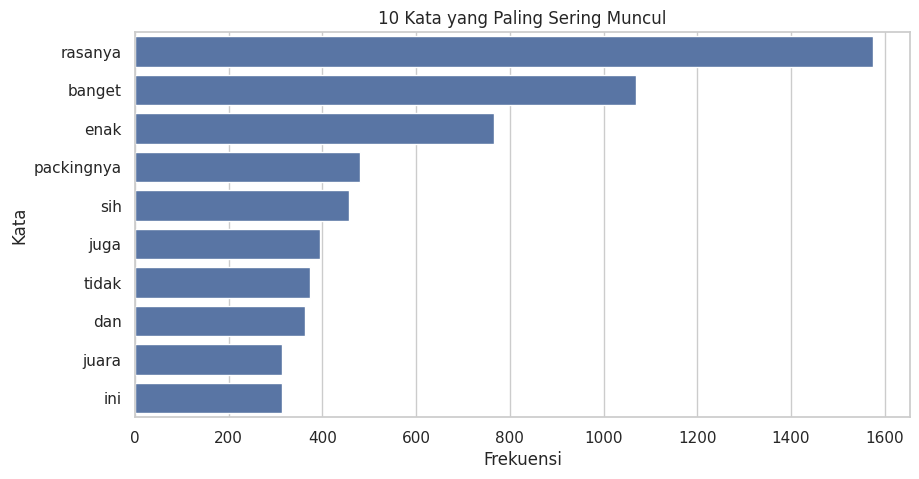

In [32]:
from collections import Counter

all_words = ' '.join(X_text['review_text_clean']).split()
word_counts = Counter(all_words)

top_words = pd.DataFrame(word_counts.most_common(10), columns=['kata', 'frekuensi'])
display(top_words)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words, x='frekuensi', y='kata')
plt.title('10 Kata yang Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

Berdasarkan hasil di atas, kata yang paling sering muncul setelah proses cleaning adalah **`rasanya`**, **`banget`**, dan **`enak`**. Hal ini menunjukkan bahwa banyak ulasan pelanggan berfokus pada **rasa makanan** dan cenderung mengekspresikan penilaian secara langsung.

Selain itu, munculnya kata seperti **`packingnya`** juga menunjukkan bahwa aspek kemasan ikut sering dibahas dalam ulasan. Sementara kata seperti **`tidak`** mengindikasikan adanya ulasan yang mengandung sentimen negatif atau penolakan, sehingga kata-kata dalam dataset tidak hanya merepresentasikan opini positif.

Secara umum, hasil ini memperlihatkan bahwa kolom `review_text` memang memuat kata-kata yang relevan untuk analisis sentimen. Namun, frekuensi kata ini hanya digunakan sebagai eksplorasi tambahan, sedangkan representasi utama yang dipakai untuk pemodelan tetap menggunakan **TF-IDF**.

### Kesimpulan

Pada tahap preprocessing data teks, kolom `review_text` dibersihkan dengan mengubah huruf menjadi lowercase, menghapus tanda baca dan angka, serta merapikan spasi. Missing value juga berhasil ditangani sehingga tidak ada lagi nilai kosong pada teks hasil cleaning.

Setelah itu, teks yang sudah dibersihkan diubah ke bentuk numerik menggunakan **TF-IDF**, sehingga diperoleh representasi fitur teks dengan ukuran **3000 baris** dan **52 fitur kata**. Dengan demikian, data teks sudah siap digunakan pada tahap pemodelan.

# Soal 7 - Preprocessing Data Citra

Pada tahap ini dilakukan preprocessing pada data citra yang direpresentasikan oleh kolom **`image_name`**. Berbeda dengan data tabular dan teks, data citra tidak dapat langsung digunakan dalam bentuk nama file, sehingga gambar perlu dibaca dari file aslinya terlebih dahulu.

Tujuan preprocessing citra adalah menyiapkan data gambar agar memiliki format yang konsisten dan siap digunakan pada tahap pemodelan. Langkah awal yang dilakukan adalah memastikan file gambar dapat diakses dengan benar, lalu menampilkan beberapa contoh gambar untuk memahami kondisi awal data citra.

In [35]:
from pathlib import Path
import os

image_col = 'image_name'

# pastikan IMAGE_DIR sudah benar dari setup awal
print("Folder gambar:", IMAGE_DIR)
print("Jumlah file gambar di folder:", len(list(Path(IMAGE_DIR).glob('*'))))

X_image = df[[image_col]].copy()

print("Jumlah data image_name:", X_image.shape[0])
print("Jumlah nilai unik image_name:", X_image[image_col].nunique())

Folder gambar: /kaggle/input/datasets/revalinaf/food-review-dataset-modul-0-ai-2026/DatasetModul0AI2026/images
Jumlah file gambar di folder: 21
Jumlah data image_name: 3000
Jumlah nilai unik image_name: 21


Berdasarkan hasil di atas, folder gambar berhasil diakses dengan benar dan berisi **21 file gambar**. Sementara itu, kolom `image_name` pada dataset memiliki **3000 data** dengan **21 nilai unik**, yang berarti file gambar yang sama digunakan berulang pada banyak baris data.

Hal ini menunjukkan bahwa data citra pada dataset memiliki variasi visual yang terbatas, karena hanya terdapat 21 gambar berbeda untuk mewakili seluruh data. Meskipun demikian, gambar tetap dapat digunakan sebagai bagian dari dataset multimodal, selama diproses dari file aslinya, bukan hanya dari nama file.

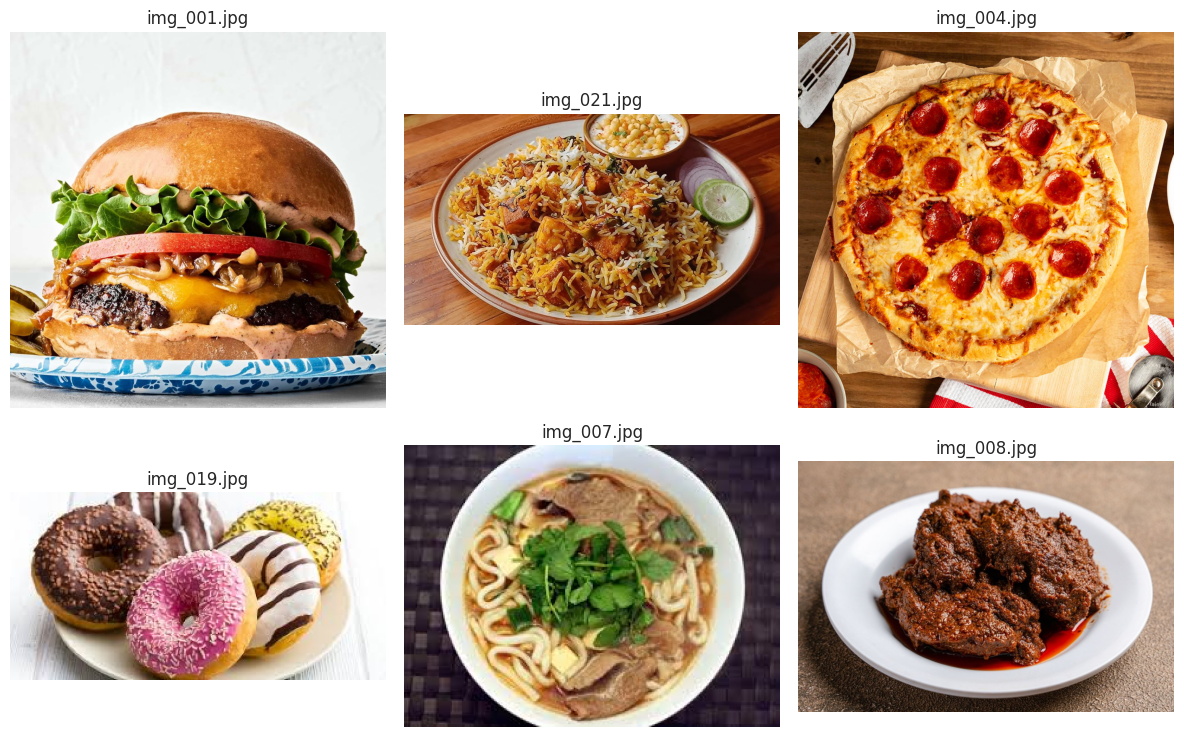

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

sample_images = X_image[image_col].dropna().unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = Path(IMAGE_DIR) / img_name
    img = Image.open(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(img_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Beberapa contoh gambar di atas menunjukkan bahwa file citra pada dataset berhasil dibaca dan ditampilkan dengan baik. Gambar-gambar tersebut merepresentasikan berbagai jenis makanan, seperti burger, nasi berbumbu, pizza, donat, mie, dan rendang.

Dari tampilan visualnya, terlihat bahwa data citra memang memuat informasi yang relevan mengenai jenis dan penampilan makanan. Hal ini menunjukkan bahwa gambar dapat menjadi sumber informasi tambahan dalam dataset multimodal, meskipun variasi gambarnya terbatas karena hanya terdapat 21 file gambar unik.

Tahap ini penting untuk memastikan bahwa data citra dapat diakses dengan benar sebelum dilakukan preprocessing lebih lanjut, seperti resizing dan normalisasi.

In [37]:
image_sizes = []

for img_name in X_image[image_col].dropna().unique():
    img_path = Path(IMAGE_DIR) / img_name
    img = Image.open(img_path)
    image_sizes.append({
        'image_name': img_name,
        'size': img.size
    })

image_sizes_df = pd.DataFrame(image_sizes)
display(image_sizes_df)

,image_name,size
0,img_001.jpg,"(1200, 1200)"
1,img_021.jpg,"(686, 386)"
2,img_004.jpg,"(1000, 1000)"
3,img_019.jpg,"(318, 159)"
4,img_007.jpg,"(259, 194)"
...,...,...
16,img_010.jpg,"(2848, 2136)"
17,img_006.jpg,"(540, 360)"
18,img_014.jpg,"(520, 360)"
19,img_020.jpg,"(1200, 800)"


Berdasarkan tabel di atas, ukuran gambar dalam dataset **tidak seragam**. Terlihat bahwa ada gambar dengan resolusi kecil seperti **(259, 194)**, ada juga yang sangat besar seperti **(6137, 4091)**.

Perbedaan ukuran ini menunjukkan bahwa data citra belum memiliki format yang konsisten. Karena model machine learning, khususnya model berbasis citra, umumnya membutuhkan input dengan ukuran yang sama, maka gambar perlu melalui proses **resizing** pada tahap preprocessing berikutnya.

Dengan demikian, hasil ini menegaskan bahwa penyamaan ukuran gambar merupakan langkah penting sebelum data citra digunakan lebih lanjut.

### Resizing gambar

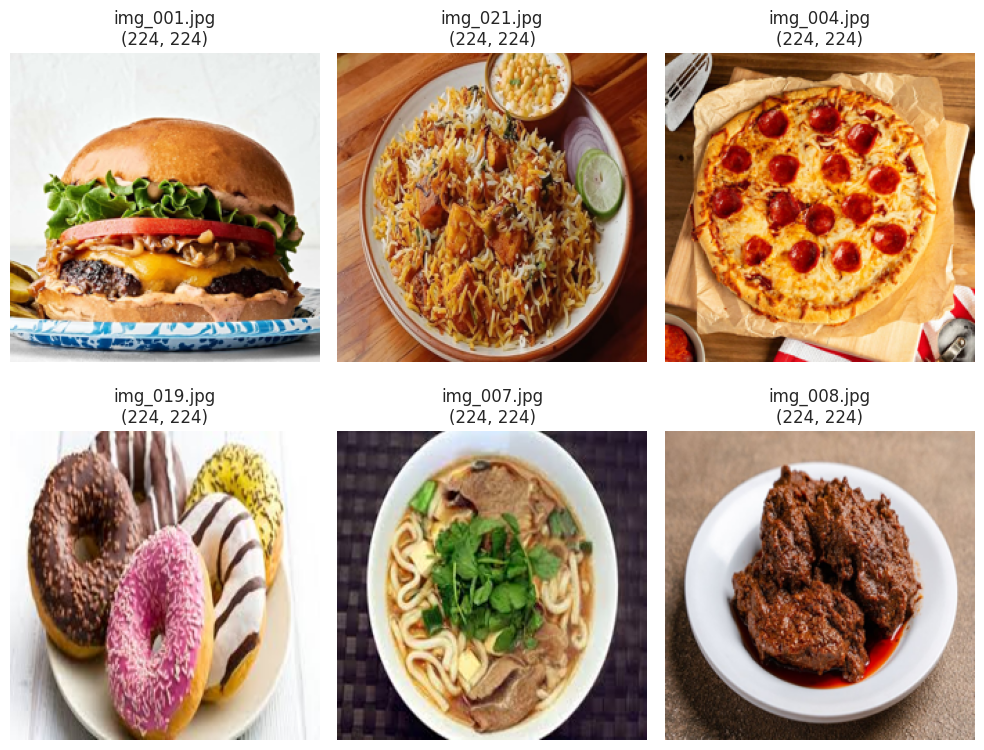

,image_name,original_size,resized_size
0,img_001.jpg,"(1200, 1200)","(224, 224)"
1,img_021.jpg,"(686, 386)","(224, 224)"
2,img_004.jpg,"(1000, 1000)","(224, 224)"
3,img_019.jpg,"(318, 159)","(224, 224)"
4,img_007.jpg,"(259, 194)","(224, 224)"
5,img_008.jpg,"(1200, 800)","(224, 224)"


In [39]:
target_size = (224, 224)

resized_images = []
sample_images = X_image[image_col].dropna().unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = Path(IMAGE_DIR) / img_name
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(target_size)
    
    resized_images.append({
        'image_name': img_name,
        'original_size': img.size,
        'resized_size': img_resized.size
    })
    
    axes[i].imshow(img_resized)
    axes[i].set_title(f'{img_name}\n{img_resized.size}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

resized_info = pd.DataFrame(resized_images)
display(resized_info)

Hasil di atas menunjukkan bahwa seluruh gambar sampel berhasil diubah ke ukuran yang sama, yaitu **224 × 224 piksel**. Sebelumnya, gambar memiliki ukuran yang berbeda-beda, tetapi setelah proses resizing semuanya menjadi seragam.

Penyamaan ukuran ini penting karena model machine learning untuk data citra umumnya membutuhkan input dengan dimensi yang konsisten. Dengan resizing, setiap gambar dapat diproses dalam format yang sama pada tahap berikutnya.

Meskipun ukuran gambar berubah, informasi visual utama dari objek makanan masih tetap terlihat. Hal ini menunjukkan bahwa resizing berhasil dilakukan tanpa menghilangkan bentuk umum dari gambar.

In [40]:
import numpy as np

sample_img_name = X_image[image_col].dropna().unique()[0]
sample_img_path = Path(IMAGE_DIR) / sample_img_name

img = Image.open(sample_img_path).convert('RGB')
img_resized = img.resize(target_size)

img_array = np.array(img_resized)
img_normalized = img_array / 255.0

print("Nama gambar:", sample_img_name)
print("Shape array gambar:", img_array.shape)
print("Nilai piksel sebelum normalisasi - min:", img_array.min(), ", max:", img_array.max())
print("Nilai piksel setelah normalisasi - min:", img_normalized.min(), ", max:", img_normalized.max())

Nama gambar: img_001.jpg
Shape array gambar: (224, 224, 3)
Nilai piksel sebelum normalisasi - min: 0 , max: 255
Nilai piksel setelah normalisasi - min: 0.0 , max: 1.0



Hasil di atas menunjukkan bahwa gambar yang sudah di-*resize* berhasil diubah ke bentuk array dengan ukuran **(224, 224, 3)**. Bentuk ini menunjukkan bahwa gambar memiliki tinggi **224 piksel**, lebar **224 piksel**, dan **3 channel warna** (RGB).

Sebelum normalisasi, nilai piksel berada pada rentang **0 sampai 255**. Setelah normalisasi, rentang nilainya berubah menjadi **0.0 sampai 1.0**. Perubahan ini penting karena membuat skala data citra menjadi lebih kecil dan lebih stabil untuk digunakan dalam proses pemodelan.

Dengan demikian, gambar sudah berhasil melalui dua tahap preprocessing dasar, yaitu **resizing** dan **normalisasi**, sehingga data citra menjadi lebih siap digunakan untuk analisis atau model berbasis gambar.

### Kesimpulan

Pada tahap preprocessing data citra, kolom `image_name` terlebih dahulu digunakan untuk mengakses file gambar asli dari folder dataset. Hasil pengecekan menunjukkan bahwa dataset memiliki **21 file gambar unik** yang digunakan berulang pada **3000 data**, sehingga variasi citra dalam dataset masih terbatas.

Beberapa contoh gambar berhasil ditampilkan dengan baik, yang menunjukkan bahwa file citra dapat diakses tanpa masalah. Selanjutnya, ukuran gambar diperiksa dan ditemukan bahwa resolusi tiap gambar tidak seragam, sehingga dilakukan proses **resizing** untuk menyeragamkan ukuran menjadi **224 × 224 piksel**.

Setelah itu, gambar diubah ke bentuk array dan dilakukan **normalisasi piksel** dari rentang **0–255** menjadi **0–1**. Dengan demikian, data citra sudah melalui preprocessing dasar yang penting dan siap digunakan pada tahap pemodelan berbasis gambar.